# Dublin Housing Market Analysis Using Python and Machine Learning

## Clustering Analysis 
### K-Means Clustering 
**Attributes used:**
- distance
- price
- baths
- beds

Optimal clusters using **Elbow Method** (k = 3). 

### Clusters Identified: 
- Cluster 0 Affordable properties. 
- Cluster 1 Mid-range properties. 
- Cluster 2 Premium properties

### Hierarchical Clustering 
Method: Ward linkage 

Dendrogram applied to determine clusters. 

In [1]:
#Load data
import pandas as pd

df = pd.read_csv("Group6_Cleaned_Dataset.csv")

# Select features for clustering
features = ["price", "beds", "baths", "distance_from_city_km"]

X = df[features]

In [2]:
#Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

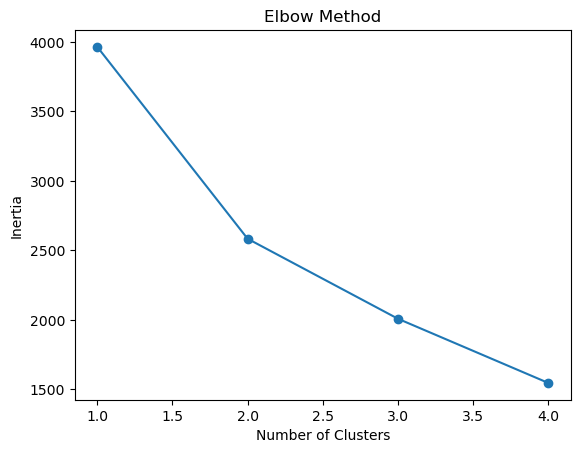

In [3]:
#K-Means
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,5), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### Elbow Method
- The model determines which attributes impact on the prediction of price the most. 
- There are distance to the city centre and number of bedrooms among the most important aspects. 
- This loop executes K-Means using varying values of clusters (k). 
- The inertia is used to measure the compactness of the clusters.

In [4]:
#Final K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print(df["kmeans_cluster"].value_counts())

kmeans_cluster
1    623
0    312
2     56
Name: count, dtype: int64


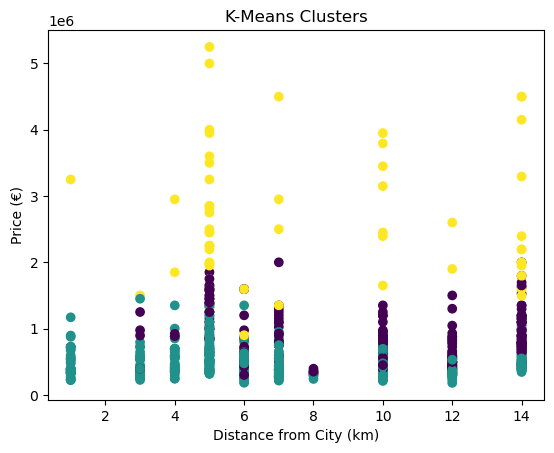

In [5]:
#Visualize
plt.scatter(df["distance_from_city_km"], df["price"], c=df["kmeans_cluster"])
plt.xlabel("Distance from City (km)")
plt.ylabel("Price (€)")
plt.title("K-Means Clusters")
plt.show()

### K-Means
K-Means clusters the properties into 3 clusters in terms of similarity.
All the properties get cluster labels (0, 1, 2).
These clusters represent:
- Affordable
- Mid-range
- Premium properties

In this plot, the grouping of houses depends on price and distance.
- The clusters are denoted by different colors.
- Helps has a visual sense of segmentation.

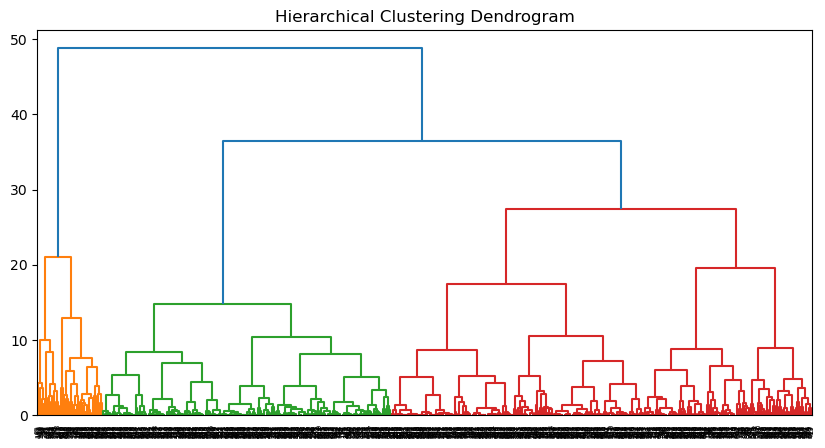

In [6]:
#hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

### Hierarchical Clustering
Hierarchical clustering clusters the data one step at a time.
Ward method prevents variance within clusters.
- Establishes a taxonomy of clusters.

The dendrogram is a tree-granted diagram indicating the formation of clusters.
- It assists in determining the number of clusters to select (by pruning the tree).

In [7]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
df["hierarchical_cluster"] = hc.fit_predict(X_scaled)

print(df["hierarchical_cluster"].value_counts())

hierarchical_cluster
0    539
2    369
1     83
Name: count, dtype: int64


In [8]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
df["hierarchical_cluster"] = hc.fit_predict(X_scaled)

print(df["hierarchical_cluster"].value_counts())

hierarchical_cluster
0    539
2    369
1     83
Name: count, dtype: int64


### Agglomerative Clustering
This is the hierarchical clustering model as it is.
- It allocates all the properties to a cluster (such as K-Means).
- Bottom-up method of use (merging clusters step by step).

In [9]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, df["kmeans_cluster"])
hc_score = silhouette_score(X_scaled, df["hierarchical_cluster"])

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hc_score)

K-Means Silhouette Score: 0.3175324829316422
Hierarchical Silhouette Score: 0.2707610428591622


### Comparison 
Silhouette score is used to determine the separation of clusters.
- Value ranges from -1 to 1:
- Closer to 1 for better clustering
- Formerly used to compare K-Means and Hierarchical performance.